# Homework 2 Solutions

46-921, Fall 2020

**Question One:**
Go to the following website:

https://www.quandl.com/data/AAII/AAII_SENTIMENT-AAII-Investor-Sentiment-Data

and download the data set. (Note that there are multiple ways of doing this,
including using the "Download" button in the upper right of the screen.)
Read these data into Python and create an appropriate data frame.
Be sure that each column is in an appropriate form (date, factor,
character, etc.)
When reading in the file, do not make any changes to the data
file itself. Resolve any issues using appropriate Python commands.

**Only the date column needs to be transformed to get things into the appropriate form.**

In [94]:
import pandas as pd

sentdat = pd.read_csv("AAII-AAII_SENTIMENT.csv")

sentdat['Date'] = pd.to_datetime(sentdat['Date'],format='%Y-%m-%d')

sentdat.head()

,Date,Bullish,Neutral,Bearish,Total,Bullish 8-Week Mov Avg,Bull-Bear Spread,Bullish Average,Bullish Average + St. Dev,Bullish Average - St. Dev,S&P 500 Weekly High,S&P 500 Weekly Low,S&P 500 Weekly Close
0,2017-09-07,0.292776,0.349810,0.357414,1.0,0.320340,-0.064638,0.382677,0.485352,0.280002,2480.38,2428.20,2465.54
1,2017-08-31,0.250000,0.351064,0.398936,1.0,0.319044,-0.148936,0.382677,0.485352,0.280002,2460.31,2428.20,2457.59
2,2017-08-24,0.280992,0.336088,0.382920,1.0,0.324766,-0.101928,0.382677,0.485352,0.280002,2474.93,2417.35,2444.04
3,2017-08-17,0.341743,0.330275,0.327982,1.0,0.326785,0.013761,0.382677,0.485352,0.280002,2474.93,2437.75,2468.11
4,2017-08-10,0.336667,0.340000,0.323333,1.0,0.324883,0.013334,0.382677,0.485352,0.280002,2490.87,2462.08,2474.02


**Question Two:**
Are there any missing values in the data set? If so, describe any features/patterns
in the missingness.

**We can see the rows with missing values below. What we notice is that there are weeks without sentiment measures, including January 11, 1996. This affected the ability to calculate the "Bullish 8-Week moving average" for the following seven weeks, not surprisingly.**

In [95]:
import numpy as np
sentdat.iloc[np.unique(np.where(sentdat.isnull())[0]),:]

,Date,Bullish,Neutral,Bearish,Total,Bullish 8-Week Mov Avg,Bull-Bear Spread,Bullish Average,Bullish Average + St. Dev,Bullish Average - St. Dev,S&P 500 Weekly High,S&P 500 Weekly Low,S&P 500 Weekly Close
1122,1996-02-29,0.45,0.28,0.27,1.0,NaN,0.18,0.386014,0.489178,0.28285,659.08,635.00,644.37
1123,1996-02-22,0.49,0.22,0.29,1.0,NaN,0.20,0.386014,0.489178,0.28285,663.00,638.79,659.08
1124,1996-02-15,0.54,0.21,0.25,1.0,NaN,0.29,0.386014,0.489178,0.28285,664.23,646.99,647.98
1125,1996-02-08,0.53,0.31,0.16,1.0,NaN,0.37,0.386014,0.489178,0.28285,656.37,641.43,656.37
1126,1996-02-01,0.54,0.31,0.15,1.0,NaN,0.39,0.386014,0.489178,0.28285,639.26,621.42,635.84
1127,1996-01-25,0.36,0.40,0.24,1.0,NaN,0.12,0.386014,0.489178,0.28285,621.62,610.65,621.62
1128,1996-01-18,0.42,0.29,0.29,1.0,NaN,0.13,0.386014,0.489178,0.28285,612.92,598.47,611.83
1129,1996-01-11,NaN,NaN,NaN,NaN,NaN,NaN,0.386014,0.489178,0.28285,619.15,597.29,601.81
1565,1987-09-04,0.42,0.17,0.41,1.0,NaN,0.01,0.386014,0.489178,0.28285,329.79,316.70,316.70
1566,1987-08-28,0.52,0.18,0.30,1.0,NaN,0.22,0.386014,0.489178,0.28285,331.38,323.04,323.04


**Question Three:**
Create a figure that shows how the proportion of investors who are
bullish/neutral/bearish changes over the __years__ of the data set.

**The following syntax will create a new data frame which has a row for each year, and entries are the average of the sentiment variables over that year.**

In [96]:
sentdat['Year'] = pd.DatetimeIndex(sentdat['Date']).year
avebyyear = sentdat.groupby('Year')['Bearish','Neutral','Bullish'].mean()

avebyyear.head()

,Bearish,Neutral,Bullish
Year,,,
1987,0.257917,0.336250,0.405833
1988,0.250769,0.476346,0.272885
1989,0.301538,0.369808,0.328654
1990,0.403077,0.323654,0.273269
1991,0.290962,0.327885,0.381154


**The plot below shows one way of illustrating how these proportions change over the years of the data set.**

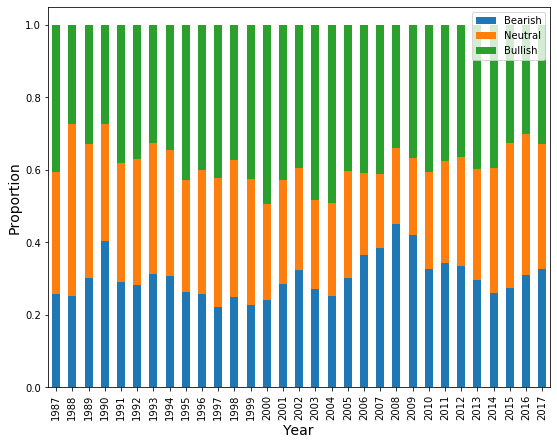

In [97]:
import matplotlib.pyplot as plt

avebyyear.plot(kind='bar',stacked=True, figsize=[9,7])

plt.xlabel("Year",size=14)
plt.ylabel("Proportion",size=14)
plt.show()

**Question Four:** A colleague wonders if there could be a seasonal effect, i.e., that
there are natural variations in investor sentiment over the course of
a year that tend to repeat from year to year. Create a plot that explores
whether or not there is evidence for this. Be sure to include a description
of your conclusion. **Do not perform any "formal"
analyses.**

In [100]:
sentdat['Month'] = pd.DatetimeIndex(sentdat['Date']).month
avebymonth = sentdat.groupby(['Year','Month'])['Year','Month','Bull-Bear Spread'].mean()
avebymonth.head()

Year  Month  Bull-Bear Spread
Year Month                               
1987 6      1987      6               NaN
     7      1987      7             0.110
     8      1987      8             0.335
     9      1987      9             0.240
     10     1987     10             0.136

**The figure below shows how the sentiment varies within each year. This could be used to compare, to see if there is a consistent pattern from year to year. Nothing is evident from this plot.**

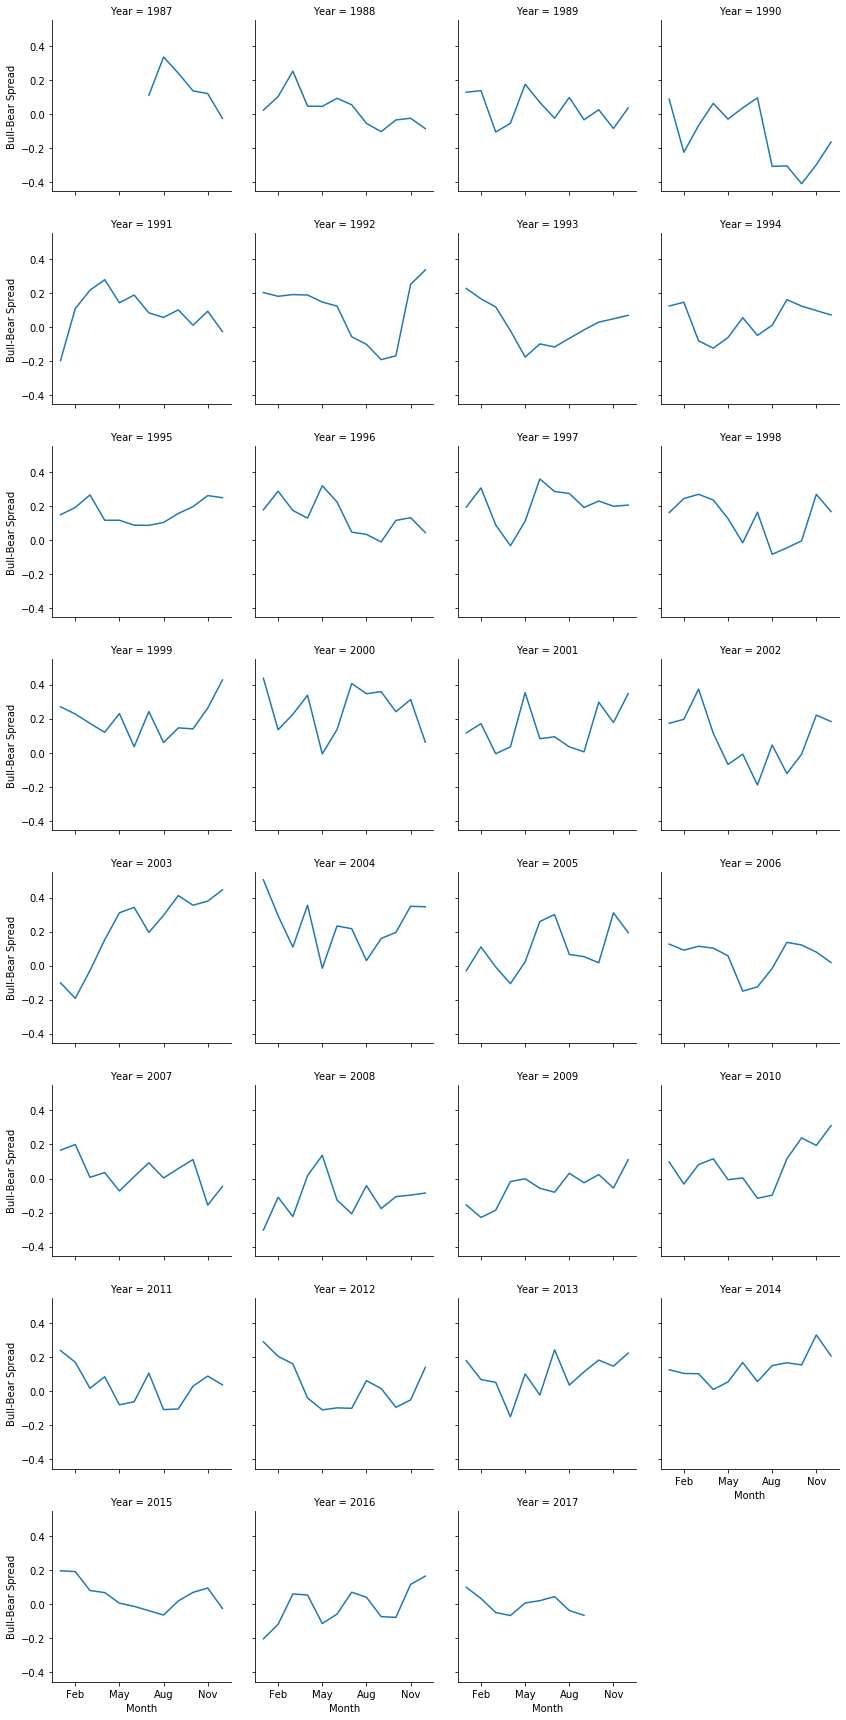

In [102]:
import seaborn as sns
fghold = sns.FacetGrid(avebymonth,col="Year",col_wrap=4)
fghold.map(plt.plot,"Month","Bull-Bear Spread")
fghold.set(xticks=[2,5,8,11])
fghold.set_xticklabels(['Feb','May','Aug','Nov'])
plt.show()

**Another approach could be to look at boxplots for each month. There is a suggestion of a dip in sentiment in the middle of the year, but the effect is slight, if any.**

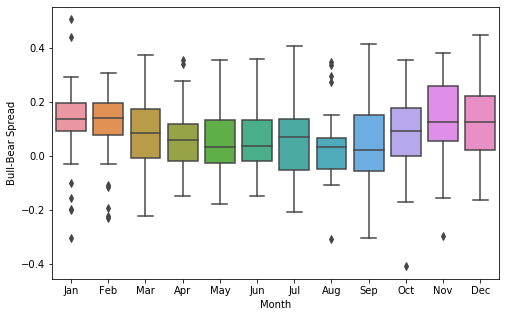

In [108]:
plt.figure(figsize=[8,5])
ax = sns.boxplot(x="Month",y="Bull-Bear Spread",data=avebymonth)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

**Question Five:** Do you think that investors are generally "correct" in their sentiments?
In other words, does their opinion regarding the future of the market
predict where the market will be over the following six months? Create a
plot that explores this. Be sure to include a description of your conclusion.
**Do not perform any "formal"
analyses.**

**Add a column to the data frame which gives the close of the S&P 500 six months (26 weeks) into the future.**

In [122]:
sentdat['SixMonthReturn'] = \
 (sentdat['S&P 500 Weekly Close'].shift(26)-sentdat['S&P 500 Weekly Close'])/sentdat['S&P 500 Weekly Close']

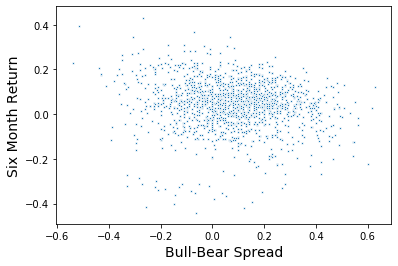

In [124]:
plt.figure(figsize=[6,4])
ax = sns.scatterplot(x="Bull-Bear Spread",y="SixMonthReturn",data=sentdat,s=5)
plt.xlabel("Bull-Bear Spread",size=14)
plt.ylabel("Six Month Return",size=14)
plt.show()

**The plot below compares sentiment and six-month return by binning sentiment into three groups, based on the Bull-Bear Spread. Values of this spread less than -0.15 are labelled as "Negative," values larger than 0.15 are labelled as "Positive," and everything else is "Mixed." If anything, the plot suggests that there is a negative relationship between returns and sentiment, but any effect is slight.**

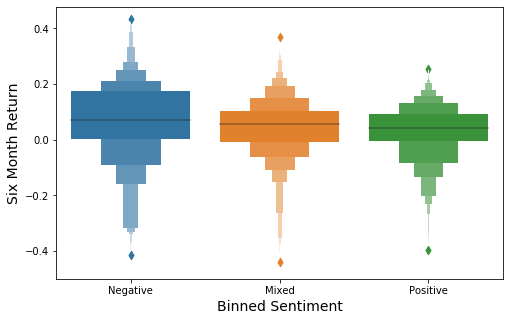

In [141]:
sentdat['BinnedSentiment']=pd.cut(sentdat['Bull-Bear Spread'],bins=[-.7,-.15,0.15,0.7],labels=['Negative','Mixed','Positive'])

plt.figure(figsize=[8,5])

ax = sns.boxenplot(x="BinnedSentiment",y="SixMonthReturn",data=sentdat)
plt.xlabel("Binned Sentiment",size=14)
plt.ylabel("Six Month Return",size=14)
plt.show()